# XGBoost Model for Stress Detection

**Author:** Eric Hernandez

## Project Overview

This notebook implements an XGBoost classifier for stress detection using the WESAD (Wearable Stress and Affect Detection) dataset. The model uses physiological sensor data from chest-worn devices to classify stress vs. non-stress states.

### Key Features:
- **Dataset:** WESAD multimodal physiological data
- **Sensors:** ECG, EDA, Respiration, Temperature, EMG, and 3-axis Accelerometer
- **Approach:** Time-windowed feature extraction with statistical features
- **Model:** XGBoost with hyperparameter optimization
- **Validation:** Subject-independent test set (S15, S16, S17)

## 1. Environment Setup

Configure the Python path to access helper modules from the parent directory and import all necessary libraries for data processing, modeling, and visualization.

In [1]:
# TODO: Remove before final submission, No longer needed in notebook
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added to path: {project_root}")


Added to path: /Users/erichernandez/Projects/Jupyter Notebooks/aai_530_final_project_group_4


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Any
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier


## 2. Data Loading and Processing Functions

### 2.1 Load Subject Data

The WESAD dataset stores individual subject data in pickle files. Each file contains:
- **Signal data:** Multi-channel physiological recordings (ECG, EDA, Respiration, Temperature, EMG, Accelerometer)
- **Labels:** Ground truth stress annotations (0=transient, 1=baseline, 2=stress, 3=amusement)

In [3]:
def load_subject_pickle(pkl_path: str) -> dict[str, Any]:
    """Load a subject's pickle file containing raw sensor data.
    
    Args:
        pkl_path: Path to the pickle file to load.
        
    Returns:
        Dictionary containing subject data with 'signal' and 'label' keys.
        The 'signal' key contains physiological sensor readings (ECG, EDA, 
        Respiration, Temperature, EMG, Accelerometer). The 'label' key 
        contains ground truth stress annotations.
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    return data


### 2.2 Time Window Creation

Physiological signals are segmented into fixed-duration windows with overlap for temporal analysis. This sliding window approach:
- Captures temporal dynamics of physiological responses
- Creates independent samples for model training
- Window size: **60 seconds** (42,000 samples at 700 Hz)
- Step size: **30 seconds** (50% overlap) to increase training examples

In [4]:
def create_windows(
    signal: np.ndarray, window_size: int, step_size: int
) -> list[np.ndarray]:
    """Create sliding windows from a physiological signal.
    
    Args:
        signal: 1D numpy array containing physiological sensor data.
        window_size: Number of samples in each window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        List of numpy arrays, where each array is a window of the signal.
    """
    windows = [
        signal[i:i + window_size]
        for i in range(0, len(signal) - window_size, step_size)
    ]
    
    return windows


### 2.3 Label Processing

Extract majority-vote labels for each window, converting multi-class labels to binary classification:
- **Stress (1):** Label 2 from original data
- **Non-stress (0):** Labels 1 (baseline) and 3 (amusement)
- **Transient (0):** Removed from analysis (transition periods between conditions)

In [5]:
def get_window_labels(
    labels: np.ndarray, window_size: int, step_size: int
) -> list[int]:
    """Extract majority-vote labels for time windows with binary classification.

    Args:
        labels: 1D numpy array of ground truth labels (0=transient, 1=baseline,
            2=stress, 3=amusement).
        window_size: Number of samples in each window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        List of binary labels where 1 indicates stress and 0 indicates non-stress.
        Windows with only transient labels are excluded.
    """
    y: list[int] = []

    for i in range(0, len(labels) - window_size, step_size):
        window = labels[i:i + window_size]

         # Remove transient labels
        window = window[window != 0]

        if len(window) == 0:
            continue

        majority = np.bincount(window).argmax()

        if majority == 2:
            # Stress
            y.append(1)
        elif majority in [1, 3]:
            # Non-stress
            y.append(0)
        else:
            continue

    return y


### 2.4 Feature Extraction

Extract **7 statistical features** from each time window for each sensor channel:
1. **Mean:** Average signal value
2. **Standard Deviation:** Signal variability
3. **Minimum:** Lowest value in window
4. **Maximum:** Highest value in window
5. **25th Percentile:** Lower quartile
6. **75th Percentile:** Upper quartile
7. **Median:** Middle value

Total features per window: **7 features × 8 channels = 56 features**

In [6]:
def extract_features(window: np.ndarray) -> list[float]:
    """Extract statistical features from a signal window.

    Args:
        window: 1D numpy array containing signal samples from a time window.
        
    Returns:
        List of 7 floating-point statistical features: mean, standard deviation,
        minimum, maximum, 25th percentile, 75th percentile, and median.
    """
    features: list[float] = [
        float(np.mean(window)),
        float(np.std(window)),
        float(np.min(window)),
        float(np.max(window)),
        float(np.percentile(window, 25)),
        float(np.percentile(window, 75)),
        float(np.median(window))
    ]
    
    return features


### 2.5 Subject Data Processing Pipeline

This function orchestrates the complete data processing pipeline for a single subject:
1. Load raw pickle data
2. Extract chest sensor signals (8 channels: ECG, EDA, Respiration, Temperature, EMG, ACC_X, ACC_Y, ACC_Z)
3. Create sliding windows for each channel
4. Extract statistical features from each window
5. Generate corresponding labels
6. Return feature matrix (X) and labels (y)

In [7]:
def process_subject(
    subject_path: str, window_size: int, step_size: int
) -> tuple[list[list[float]], list[int]]:
    """Process a single subject's data through the complete feature extraction pipeline.
    
    Args:
        subject_path: Path to the subject's pickle file.
        window_size: Number of samples in each time window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        Tuple containing:
            - Feature matrix (list of feature vectors), where each feature vector
              contains 56 floats (7 features × 8 sensor channels).
            - Labels (list of integers), where 1 indicates stress and 0 indicates
              non-stress.
    """
    subject_data = load_subject_pickle(subject_path)

    chest = subject_data["signal"]["chest"]
    labels = subject_data["label"]

    ecg = chest["ECG"]
    eda = chest["EDA"]
    resp = chest["Resp"]
    temp = chest["Temp"]
    emg = chest["EMG"]
    acc = chest["ACC"]  # shape: (n_samples, 3)

    # Handle ACC channels separately
    acc_x = acc[:, 0]
    acc_y = acc[:, 1]
    acc_z = acc[:, 2]

    ecg_w = create_windows(ecg, window_size, step_size)
    eda_w = create_windows(eda, window_size, step_size)
    resp_w = create_windows(resp, window_size, step_size)
    temp_w = create_windows(temp, window_size, step_size)
    emg_w = create_windows(emg, window_size, step_size)

    # Create windows for each ACC channel
    acc_x_w = create_windows(acc_x, window_size, step_size)
    acc_y_w = create_windows(acc_y, window_size, step_size)
    acc_z_w = create_windows(acc_z, window_size, step_size)

    y = get_window_labels(labels, window_size, step_size)

    X: list[list[float]] = []
    valid_len = min(len(y), len(ecg_w))

    for i in range(valid_len):
        features: list[float] = []
        
        features += extract_features(ecg_w[i])
        features += extract_features(eda_w[i])
        features += extract_features(resp_w[i])
        features += extract_features(temp_w[i])
        features += extract_features(emg_w[i])

        features += extract_features(acc_x_w[i])
        features += extract_features(acc_y_w[i])
        features += extract_features(acc_z_w[i])

        X.append(features)

    return X, y[:valid_len]


## 3. Dataset Preparation

### 3.1 Process All Subjects

Process physiological data from all WESAD subjects using the following parameters:
- **Sampling Rate:** 700 Hz (chest sensor frequency)
- **Window Duration:** 60 seconds
- **Window Size:** 42,000 samples (700 Hz × 60 sec)
- **Step Size:** 21,000 samples (50% overlap)

This iterates through all subject folders, extracts features, and aggregates them into a unified dataset.

In [8]:
DATASET_PATH: str = '../data/WESAD'

# Sampling frequency and window parameters
SAMPLING_RATE_HZ: int = 700
WINDOW_SEC: int = 60
WINDOW_SIZE: int = SAMPLING_RATE_HZ * WINDOW_SEC
STEP_SIZE: int = WINDOW_SIZE // 2  # 50% overlap

all_X: list[list[float]] = []
all_y: list[int] = []
all_subject_ids: list[str] = []

subjects: list[str] = sorted([
    d for d in os.listdir(DATASET_PATH)
    if d.startswith("S")
])

for subject in subjects:
    subject_path: str = os.path.join(DATASET_PATH, subject, f"{subject}.pkl")

    if not os.path.exists(subject_path):
        continue

    print(f"Processing {subject}...")
    X, y = process_subject(subject_path, WINDOW_SIZE, STEP_SIZE)

    all_X.extend(X)
    all_y.extend(y)
    all_subject_ids.extend([subject] * len(y))


Processing S10...


/var/folders/kq/x4dtsk613y129hqcy6rkbkrm0000gn/T/ipykernel_9675/3839997787.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1')


Processing S11...
Processing S13...
Processing S14...
Processing S15...
Processing S16...
Processing S17...
Processing S2...
Processing S3...
Processing S4...
Processing S5...
Processing S6...
Processing S7...
Processing S8...
Processing S9...


### 3.2 Create Feature DataFrame

Organize extracted features into a structured DataFrame with:
- **56 feature columns:** 7 statistical features × 8 sensor channels
- **Label column:** Binary stress classification (0=non-stress, 1=stress)
- **Subject ID column:** Track which subject each sample belongs to

This enables subject-independent validation and prevents data leakage.

In [9]:
columns: list[str] = [
    "ECG_mean", "ECG_std", "ECG_min", "ECG_max", "ECG_25th", "ECG_75th", "ECG_median",
    "EDA_mean", "EDA_std", "EDA_min", "EDA_max", "EDA_25th", "EDA_75th", "EDA_median",
    "RESP_mean", "RESP_std", "RESP_min", "RESP_max", "RESP_25th", "RESP_75th", "RESP_median",
    "TEMP_mean", "TEMP_std", "TEMP_min", "TEMP_max", "TEMP_25th", "TEMP_75th", "TEMP_median",
    "EMG_mean", "EMG_std", "EMG_min", "EMG_max", "EMG_25th", "EMG_75th", "EMG_median",
    "ACC_X_mean", "ACC_X_std", "ACC_X_min", "ACC_X_max", "ACC_X_25th", "ACC_X_75th", "ACC_X_median",
    "ACC_Y_mean", "ACC_Y_std", "ACC_Y_min", "ACC_Y_max", "ACC_Y_25th", "ACC_Y_75th", "ACC_Y_median",
    "ACC_Z_mean", "ACC_Z_std", "ACC_Z_min", "ACC_Z_max", "ACC_Z_25th", "ACC_Z_75th", "ACC_Z_median"
]

df: pd.DataFrame = pd.DataFrame(all_X, columns=columns)
df["label"] = all_y
df["subject"] = all_subject_ids

df.describe()


,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_25th,ECG_75th,ECG_median,EDA_mean,EDA_std,EDA_min,...,ACC_Y_75th,ACC_Y_median,ACC_Z_mean,ACC_Z_std,ACC_Z_min,ACC_Z_max,ACC_Z_25th,ACC_Z_75th,ACC_Z_median,label
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,...,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,0.001082,0.258495,-0.631291,1.427160,-0.093443,0.034790,-0.026941,4.223885,0.058185,3.984789,...,-0.029094,-0.045952,-0.278389,0.061842,-0.468194,-0.026152,-0.317691,-0.243988,-0.280571,0.304458
std,0.000507,0.061374,0.237107,0.190688,0.041020,0.032576,0.023404,3.021945,0.146955,2.975364,...,0.107106,0.107300,0.295288,0.072158,0.345320,0.480285,0.288954,0.320619,0.305060,0.460371
min,-0.001824,0.111402,-1.499680,0.744095,-0.334030,-0.017624,-0.105698,0.728551,0.007825,0.416183,...,-0.469000,-0.474200,-0.942175,0.004229,-4.779800,-0.918000,-0.945400,-0.939400,-0.942200,0.000000
25%,0.000851,0.230485,-0.777649,1.497299,-0.111511,0.012051,-0.042892,1.684937,0.013500,1.485062,...,-0.060400,-0.073800,-0.439890,0.014636,-0.601400,-0.338800,-0.477000,-0.429600,-0.448800,0.000000
50%,0.001138,0.259799,-0.578384,1.499222,-0.087204,0.025131,-0.029251,3.093501,0.018515,2.884674,...,-0.016200,-0.030600,-0.272959,0.031858,-0.447800,-0.031800,-0.321800,-0.232600,-0.281000,0.000000
75%,0.001379,0.292022,-0.446732,1.499451,-0.070965,0.048809,-0.019180,6.219160,0.039984,5.997086,...,0.027000,0.011000,-0.120819,0.078681,-0.303200,0.204600,-0.169800,-0.067000,-0.122600,1.000000
max,0.004007,0.476084,-0.241104,1.499954,0.001144,0.186916,0.037033,14.134826,2.517641,12.770844,...,0.248650,0.213200,0.735563,0.577842,0.665000,4.508200,0.719400,0.766600,0.731000,1.000000


## 4. Train-Test Split

### Subject-Independent Validation

Use **subject-independent** cross-validation to ensure model generalization:
- **Test Set:** S15, S16, S17 (held-out subjects)
- **Training Set:** All remaining subjects

This approach simulates real-world deployment where the model encounters new, unseen individuals. Features are scaled using StandardScaler fitted only on training data to prevent data leakage.

In [10]:
test_subjects: list[str] = ["S15", "S16", "S17"]
train_subjects: list[str] = [s for s in subjects if s not in test_subjects]

# Print train/test split info
print(f"Train subjects: {train_subjects}")
print(f"Test subjects: {test_subjects}")

train_df: pd.DataFrame = df[df["subject"].isin(train_subjects)]
test_df: pd.DataFrame = df[df["subject"].isin(test_subjects)]

X_train: pd.DataFrame = train_df.drop(["label", "subject"], axis=1)
y_train: pd.Series = train_df["label"]

X_test: pd.DataFrame = test_df.drop(["label", "subject"], axis=1)
y_test: pd.Series = test_df["label"]

# Standardize features using training set statistics
scaler: StandardScaler = StandardScaler()
X_train_scaled: np.ndarray = scaler.fit_transform(X_train)
X_test_scaled: np.ndarray = scaler.transform(X_test)


Train subjects: ['S10', 'S11', 'S13', 'S14', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Test subjects: ['S15', 'S16', 'S17']


## 5. Model Training

### XGBoost with Hyperparameter Optimization

Use **RandomizedSearchCV** to find optimal hyperparameters:
- **n_estimators:** Number of boosting rounds [50, 100, 150]
- **max_depth:** Maximum tree depth [3, 5, 8]
- **learning_rate:** Step size shrinkage [0.05, 0.1, 0.2]

Configuration:
- **Cross-validation:** 3-fold CV on training data
- **Random search iterations:** 5
- **Evaluation metric:** Log loss
- **Random state:** 42 (reproducibility)

In [11]:
model: XGBClassifier = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
)

parameters_xgb: dict[str, list[int] | list[float]] = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

model_optimized: RandomizedSearchCV = RandomizedSearchCV(
    model,
    parameters_xgb,
    n_iter=5,
    cv=3,
    random_state=42
)

model_optimized.fit(
    X_train_scaled, 
    y_train
)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default 

## 6. Model Evaluation

### 6.1 Classification Performance

Evaluate model performance on the held-out test set using:
- **Precision:** Accuracy of positive predictions
- **Recall:** Coverage of actual positives
- **F1-Score:** Harmonic mean of precision and recall
- **Support:** Number of samples per class

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --- Predictions ---
predictions = model_optimized.predict(X_test_scaled)

# --- Core Metrics ---
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, pos_label=1)
recall = recall_score(y_test, predictions, pos_label=1)
f1 = f1_score(y_test, predictions, pos_label=1)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# --- Detailed Report ---
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=["Non-Stress", "Stress"], digits=4))



Accuracy : 0.7291666666666666
Precision: 0.6470588235294118
Recall   : 0.29333333333333333
F1 Score : 0.4036697247706422

Classification Report:
              precision    recall  f1-score   support

  Non-Stress     0.7427    0.9273    0.8248       165
      Stress     0.6471    0.2933    0.4037        75

    accuracy                         0.7292       240
   macro avg     0.6949    0.6103    0.6142       240
weighted avg     0.7128    0.7292    0.6932       240



### 6.2 Feature Importance Analysis

Visualize which physiological features contribute most to stress classification. XGBoost provides feature importance scores based on:
- Gain-based importance (improvement in accuracy)
- How frequently features are used for splitting

This helps identify:
- **Most informative sensors** for stress detection
- **Redundant features** that could be removed
- **Physiological patterns** associated with stress

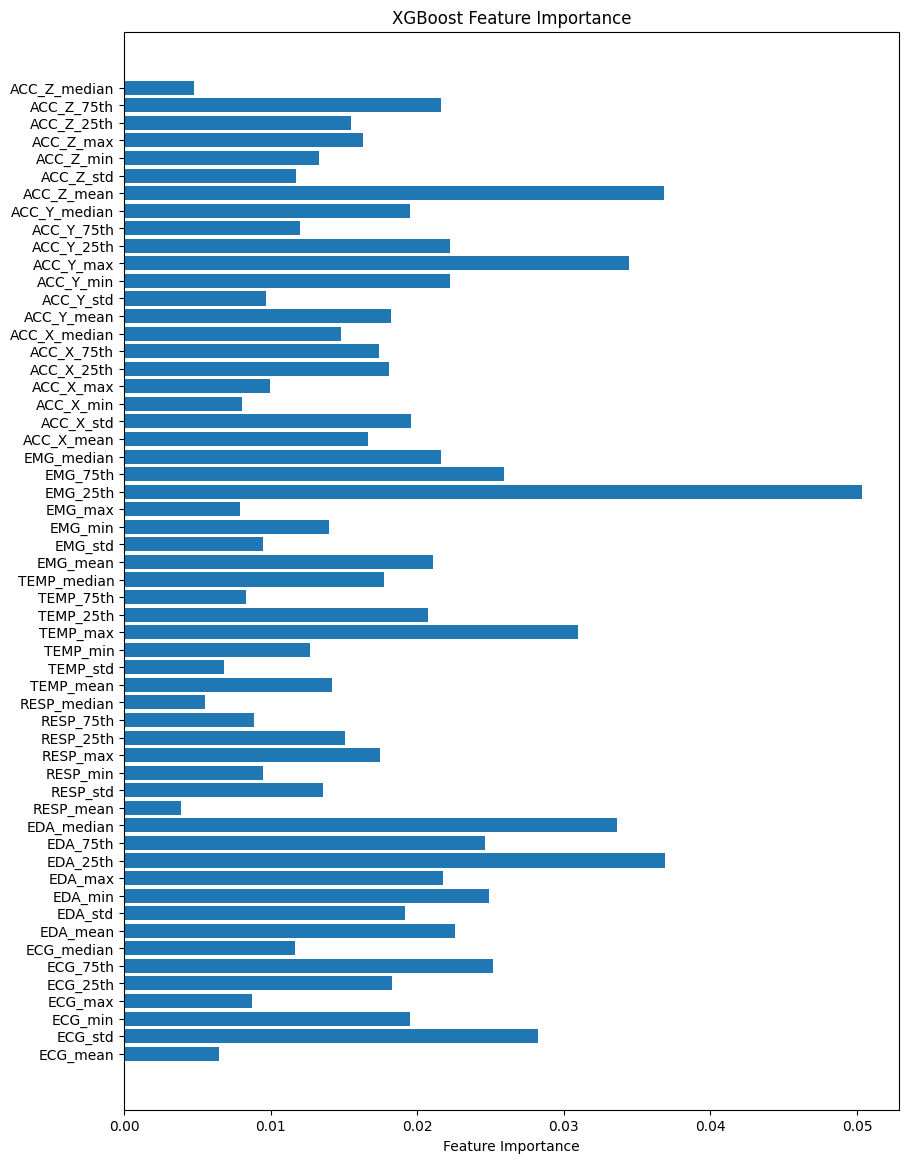

In [13]:
# Visualize feature importance
plt.figure(figsize=(10, 14))
plt.barh(columns, model_optimized.best_estimator_.feature_importances_)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()


### 6.3 Confusion Matrix

The confusion matrix provides detailed breakdown of prediction performance:
- **True Negative (TN):** Correctly identified non-stress samples
- **False Positive (FP):** Non-stress incorrectly classified as stress (Type I error)
- **False Negative (FN):** Stress incorrectly classified as non-stress (Type II error)
- **True Positive (TP):** Correctly identified stress samples

This visualization helps identify if the model has bias toward specific classes and assess the clinical impact of misclassifications.

True Negative (TN): 153
False Positive (FP): 12
False Negative (FN): 53
True Positive (TP): 22


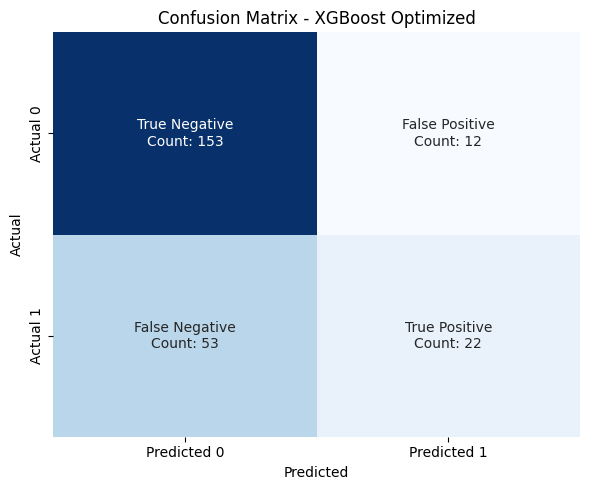

In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
grouped_labels = [f"{label}\nCount: {value}" for label, value in zip(labels, cm.ravel())]
grouped_labels = np.asarray(grouped_labels).reshape(2, 2)

# Unpack the confusion matrix values
tn, fp, fn, tp = cm.ravel()

# Print each value with its label
print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=grouped_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix - XGBoost Optimized')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



### 6.4 ROC Curve Analysis

The **Receiver Operating Characteristic (ROC)** curve evaluates the model's discrimination ability across all classification thresholds:
- **X-axis:** False Positive Rate (FPR) - proportion of non-stress incorrectly classified
- **Y-axis:** True Positive Rate (TPR) / Recall - proportion of stress correctly identified
- **AUC (Area Under Curve):** Overall model performance metric
  - AUC = 1.0: Perfect classifier
  - AUC = 0.5: Random classifier
  - AUC > 0.8: Generally considered good performance

The ROC curve helps select optimal classification thresholds based on application requirements (e.g., prioritizing sensitivity over specificity).

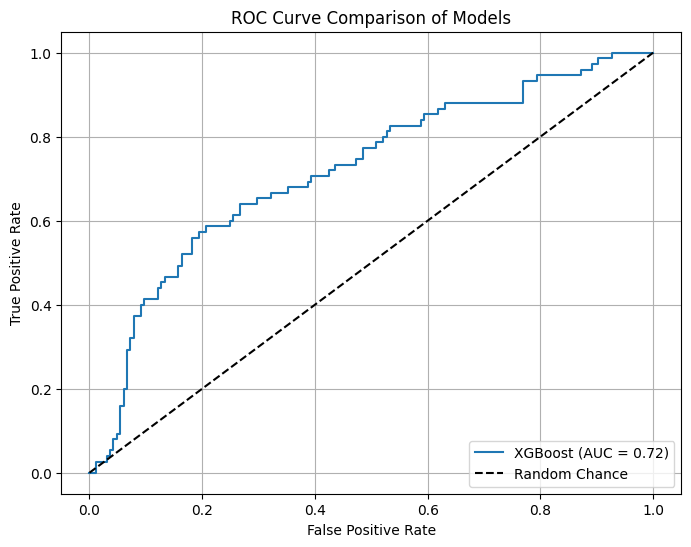

In [15]:
plt.figure(figsize=(8, 6))

# XGBoost Optimized
probs_xgb = model_optimized.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.2f})")

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
